### Install Required Packages

In [ ]:
%%capture
%pip install quantumrings-toolkit-qiskit
%pip install qiskit

In [1]:
#
# Setup your account
# You can also save your account locally using the class method QrRuntimeService.save_account(...) and
# invoke the QrRuntimeService class constructor without any arguments.
#

import os

my_token = os.environ["QR_TOKEN"]
my_name = os.environ["QR_ACCOUNT"]

#
# Set the backend of your choice, depending upon the task and your hardware configuration.
# See SDK documentation for additional help.
#

my_backend = "scarlet_quantum_rings"

In [2]:
from qiskit.circuit import QuantumCircuit
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister, AncillaRegister
from qiskit.visualization import plot_histogram
from matplotlib import pyplot as plt

from matplotlib import pyplot as plt

In [3]:
from quantumrings.toolkit.qiskit import QrRuntimeService

service = QrRuntimeService( token = my_token , name = my_name)
backend = service.backend(name = my_backend, precision = "double", gpu = 0, num_qubits = 12)

In [4]:
#from quantumrings.toolkit.qiskit import QrBackendV2
#backend = QrBackendV2(token = my_token, name = my_name, backend = my_backend, precision = "double", gpu = 0, num_qubits = 12)

In [5]:
shots = 1000
numberofqubits = backend.num_qubits
q = QuantumRegister(numberofqubits , 'q')
c = ClassicalRegister(numberofqubits , 'c')
qc = QuantumCircuit(q, c)


# Create the GHZ state (Greenberger–Horne–Zeilinger)
qc.h(0);
for i in range (qc.num_qubits - 1):
    qc.cx(i, i + 1);

# Measure all qubits
qc.measure_all();

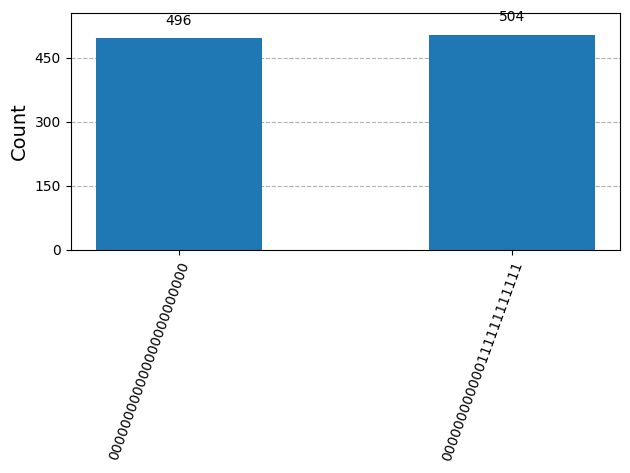

In [6]:
job = backend.run(qc, shots = shots)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)